In [1]:
import pandas as pd
import math
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import statistics as st
from scipy.stats import chi2

In [2]:
n = 14
a = -0.5
sigma = 2
gamma = 0.95
M = 1800
K = 170

Часть II

1. Смоделировать M выборок из n значений нормально распределенной случайной 
величины X с параметрами (a, sigma^2). По каждой из M выборок с надежностью gamma найти 
интервальную оценку (доверительный интервал) для дисперсии случайной величины X.

По результатам моделирования найти точечную оценку gamma* надежности gamma.

In [3]:
count = 0
for j in range(0, M):
    sample_i = np.random.normal(a, sigma, n)
    
    S = np.var(sample_i, ddof=1)
    chi2_lower, chi2_upper = sts.chi2.interval(gamma, n-1)


    right_bound = ((n-1) * S) / chi2_upper
    left_bound = ((n-1) * S) / chi2_lower
    
    if right_bound<sigma**2 and left_bound>sigma**2:
        count +=1

GAMMA = count/M
print(GAMMA)

0.9494444444444444


2. Повторив пункт 1. K раз, получите массив из K значений оценки gamma*. Найдите 
выборочные числовые характеристики оценки gamma*, постройте гистограмму относительных 
частот и бокс-плот. Каким может быть закон распределения оценки gamma* ? Чему равны 
математическое ожидание и дисперсия оценки gamma*?

In [4]:
K_list = []
for i in range(0, K):
    count = 0
    for j in range(0, M):
        sample_item = np.random.normal(a, sigma, n)

        S = np.var(sample_item, ddof=1)
        chi2_lower, chi2_upper = sts.chi2.interval(gamma, n-1)

        l_bound = ((n-1) * S) / chi2_upper
        r_bound = ((n-1) * S) / chi2_lower
        
        if l_bound<sigma**2 and r_bound>sigma**2:
            count +=1

    K_list.append(count/M)

In [5]:
print("Среднее значение:", np.mean(K_list))
print("Дисперсия:", np.var(K_list, ddof = 1))
print("Стандартное отклонение:", np.std(K_list))
print("Медиана:",np.median(K_list))
print("Минимальное значение:", np.min(K_list))
print("Максимальное значение:", np.max(K_list))

Среднее значение: 0.9496405228758169
Дисперсия: 2.8918882915866317e-05
Стандартное отклонение: 0.005361788119637947
Медиана: 0.9497222222222221
Минимальное значение: 0.9355555555555556
Максимальное значение: 0.9622222222222222


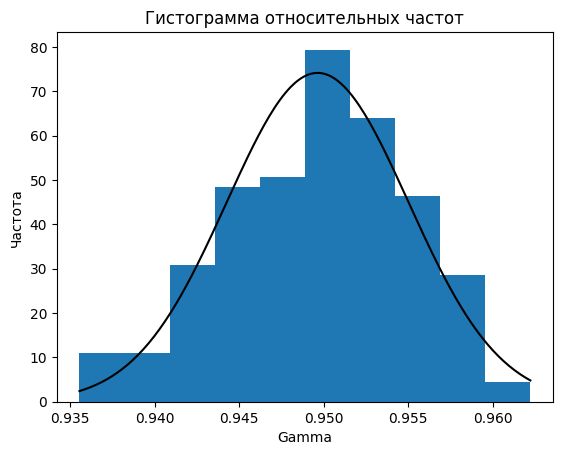

In [6]:
plt.hist(K_list, density=True, bins = 'auto')
plt.title('Гистограмма относительных частот')
plt.xlabel('Gamma')
plt.ylabel('Частота')
x = np.linspace(np.min(K_list), np.max(K_list), K)
y = sts.norm.pdf(x, loc = np.mean(K_list), scale = math.sqrt(np.var(K_list, ddof = 1)))
plt.plot(x, y, color = "black")
plt.show()


Первый квартиль: 0.9456944444444445
Второй квартиль: 0.9497222222222221
Третий квартиль: 0.9533333333333334
Межквартильный диапозон: 0.007638888888888862
Нижний предел: 0.9342361111111113
Верхний предел: 0.9647916666666667
Число выбросов: 0
Выбросы: 


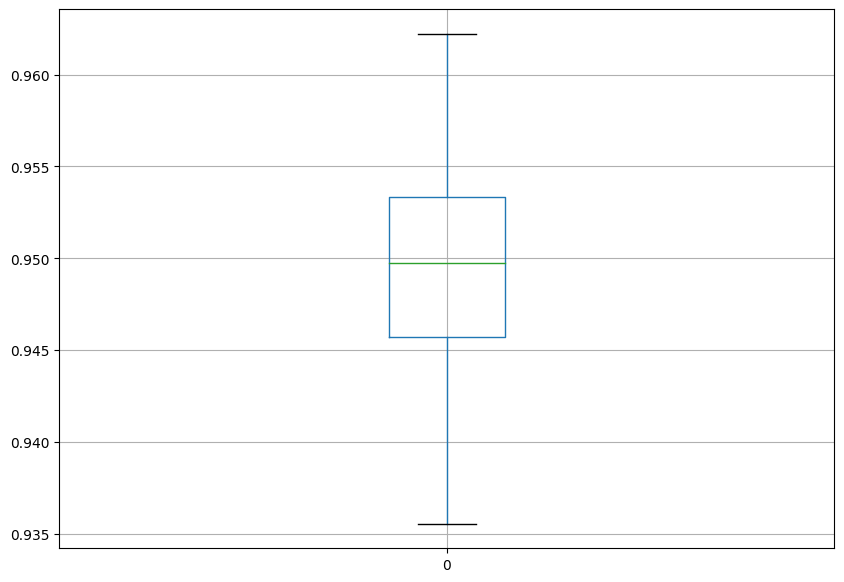

In [7]:
d = pd.DataFrame(data=K_list)
d.boxplot(figsize = (10, 7))


q_1 = np.percentile(K_list, 25)
print(f'Первый квартиль: {q_1}')
q_2 = np.percentile(K_list, 50)
print(f'Второй квартиль: {q_2}')
q_3 = np.percentile(K_list, 75)
print(f'Третий квартиль: {q_3}')
iqr = q_3 - q_1
print(f'Межквартильный диапозон: {iqr}')
lower_bound = q_1 - 1.5 * iqr
print(f'Нижний предел: {lower_bound}')
upper_bound = q_3 + 1.5 * iqr
print(f'Верхний предел: {upper_bound}')

outliers = []
for i in K_list:
    if (i < lower_bound) or (i > upper_bound):
        outliers.append(i)
number_outliers = len(outliers)

print(f'Число выбросов: {number_outliers}')
print('Выбросы: ')
for i in range(len(outliers)):
    print(f'{outliers[i]}\t')

3. Смоделировать M выборок из n значений случайной величины W, закон распределения 
которой указан в Вашем варианте. По каждой из M выборок с надежностью gamma найти 
интервальную оценку (доверительный интервал) для дисперсии случайной величины W. 
По результатам моделирования найти точечную оценку gamma* надежности gamma.

In [8]:
#U1...U5 - выборка Хи-квадрат с кол-вом степеней свободы 5
# дисперсия хи-квадрат = 2*степень свободы. Поэтому:
#DW = D((U1 + U2 + U3 + U4 + U5)/5) = 1/25 * D(U1 + U 2+ U3 + U4 + U5) = 1/25 * (DU1 + DU2 + DU3 + DU4 + DU5) = 40/25 = 8/5
DW = 8/5
count = 0
df = 4
for i in range(0, M):
    
    sample_W = []
    
    for _ in range(0, n):
        U_values = chi2.rvs(df, size=5)
        W = (1/5) * np.sum(U_values)
        sample_W.append(W)
    
    w_var = np.var(sample_W, ddof=1)
    chi2_lower, chi2_upper = chi2.interval(gamma, n-1)
    #границы доверительного интервала для дисперсии
    l_bound = ((n-1) * w_var) / chi2_upper
    r_bound = ((n-1) * w_var) / chi2_lower

    if l_bound<DW and r_bound>DW:
        count +=1

GAMMA = count/M
print(GAMMA)

0.9272222222222222


4. Повторив пункт 3. K раз, получите массив из K значений оценки gamma*. Найдите 
выборочные числовые характеристики оценки gamma*, постройте гистограмму относительных 
частот и бокс-плот. Каким может быть закон распределения оценки gamma* ?

In [10]:
K_list_2 = []
df = 4
for i in range(0, K):
    count = 0
    for j in range(0, M):
        sample_W = []
        for _ in range(0, n):
            U_values = chi2.rvs(df, size=4)
            W = (1/5) * np.sum(U_values)
            sample_W.append(W)
    
        s_3 = np.var(sample_W, ddof=1)
        chi2_lower, chi2_upper = chi2.interval(gamma, n-1)
        l_bound = ((n-1) * s_3) / chi2_upper
        r_bound = ((n-1) * s_3) / chi2_lower

        if l_bound<DW and r_bound>DW:
            count +=1

    K_list_2.append(count/M)

In [15]:
print("Среднее значение:", np.mean(K_list_2))
print("Дисперсия:", np.var(K_list_2))
print("Стандартное отклонение:", np.std(K_list_2))
print("Медиана:",np.median(K_list_2))
print("Минимальное значение:", np.min(K_list_2))
print("Максимальное значение:", np.max(K_list_2))

Среднее значение: 0.9033235294117647
Дисперсия: 5.4925466700841574e-05
Стандартное отклонение: 0.007411171749517182
Медиана: 0.9038888888888889
Минимальное значение: 0.8855555555555555
Максимальное значение: 0.9216666666666666


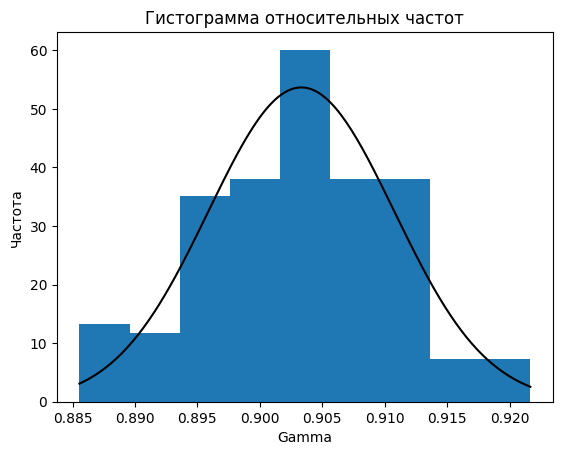

In [18]:
plt.hist(K_list_2, density=True, bins = 'auto')
plt.title('Гистограмма относительных частот')
plt.xlabel('Gamma')
plt.ylabel('Частота')

x = np.linspace(np.min(K_list_2), np.max(K_list_2), K)
y = sts.norm.pdf(x, loc = np.mean(K_list_2), scale = math.sqrt(np.var(K_list_2, ddof = 1)))
plt.plot(x, y, color = "black")
plt.show()

Первый квартиль: 0.8979166666666667
Второй квартиль: 0.9038888888888889
Третий квартиль: 0.9093055555555556
Межквартильный диапозон: 0.011388888888888893
Нижний предел: 0.8808333333333334
Верхний предел: 0.9263888888888889
Число выбросов: 0
Выбросы: 


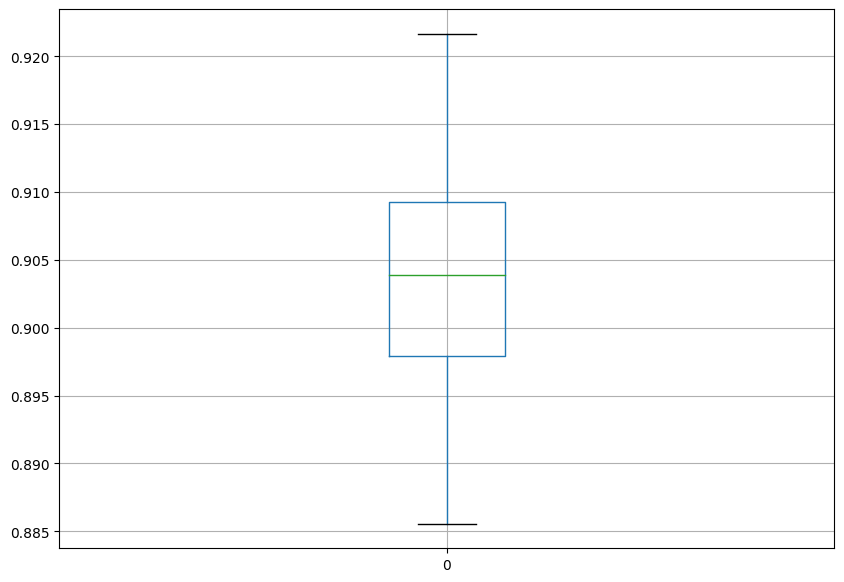

In [17]:
d = pd.DataFrame(data=K_list_2)
d.boxplot(figsize = (10, 7))


q_1 = np.percentile(K_list_2, 25)
print(f'Первый квартиль: {q_1}')
q_2 = np.percentile(K_list_2, 50)
print(f'Второй квартиль: {q_2}')
q_3 = np.percentile(K_list_2, 75)
print(f'Третий квартиль: {q_3}')
iqr = q_3 - q_1
print(f'Межквартильный диапозон: {iqr}')
lower_bound = q_1 - 1.5 * iqr
print(f'Нижний предел: {lower_bound}')
upper_bound = q_3 + 1.5 * iqr
print(f'Верхний предел: {upper_bound}')

outliers = []
for i in K_list_2:
    if (i < lower_bound) or (i > upper_bound):
        outliers.append(i)
number_outliers = len(outliers)

print(f'Число выбросов: {number_outliers}')
print('Выбросы: ')
for i in range(len(outliers)):
    print(f'{outliers[i]}\t')